In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# Load Breast Cancer dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", data.target_names)

Dataset shape: (569, 30)
Target shape: (569,)
Classes: ['malignant' 'benign']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data standardized successfully.")

Training data standardized successfully.


In [ ]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

In [ ]:
class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0

    def fit(self, X, y):

        # Number of samples and features
        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent
        for i in range(self.epochs):

            # Linear equation
            linear_model = np.dot(X, self.weights) + self.bias

            # Sigmoid activation
            predictions = sigmoid(linear_model)

            # Calculate gradients
            dw = (1 / n_samples) * np.dot(X.T, (predictions - y))
            db = (1 / n_samples) * np.sum(predictions - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_probability(self, X):

        linear_model = np.dot(X, self.weights) + self.bias

        return sigmoid(linear_model)

    def predict(self, X):

        probabilities = self.predict_probability(X)

        # Convert probability into class
        return (probabilities >= 0.5).astype(int)

In [ ]:
# Create Logistic Regression model
logistic_model = LogisticRegressionScratch(
    learning_rate=0.01,
    epochs=2000
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
accuracy_lr = accuracy_score(y_test, y_pred_logistic)
precision_lr = precision_score(y_test, y_pred_logistic)
recall_lr = recall_score(y_test, y_pred_logistic)
f1_lr = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1-Score :", f1_lr)

Logistic Regression Results
--------------------------------
Accuracy : 0.9736842105263158
Precision: 0.9859154929577465
Recall   : 0.9722222222222222
F1-Score : 0.9790209790209791


In [ ]:
class PerceptronScratch:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0

    def predict(self, X):

        linear_output = np.dot(X, self.weights) + self.bias

        return np.where(linear_output >= 0, 1, 0)

    def fit(self, X, y):

        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Training
        for epoch in range(self.epochs):

            for i in range(n_samples):

                # Prediction for one sample
                linear_output = np.dot(X[i], self.weights) + self.bias

                prediction = 1 if linear_output >= 0 else 0

                # Calculate error
                error = y[i] - prediction

                # Update weights
                self.weights += self.learning_rate * error * X[i]

                # Update bias
                self.bias += self.learning_rate * error

In [ ]:
# Create Perceptron model
perceptron_model = PerceptronScratch(
    learning_rate=0.01,
    epochs=100
)

# Train the model
perceptron_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_perceptron = perceptron_model.predict(X_test_scaled)

print("Perceptron training completed.")

Perceptron training completed.


In [ ]:
accuracy_p = accuracy_score(y_test, y_pred_perceptron)
precision_p = precision_score(y_test, y_pred_perceptron)
recall_p = recall_score(y_test, y_pred_perceptron)
f1_p = f1_score(y_test, y_pred_perceptron)

print("Perceptron Results")
print("--------------------------------")
print("Accuracy :", accuracy_p)
print("Precision:", precision_p)
print("Recall   :", recall_p)
print("F1-Score :", f1_p)

Perceptron Results
--------------------------------
Accuracy : 0.9473684210526315
Precision: 0.9583333333333334
Recall   : 0.9583333333333334
F1-Score : 0.9583333333333334


In [ ]:
print("\nComparison of Logistic Regression and Perceptron")
print("------------------------------------------------")

print(f"{'Metric':<15} {'Logistic Regression':<20} {'Perceptron':<15}")
print("-" * 55)

print(f"{'Accuracy':<15} {accuracy_lr:<20.4f} {accuracy_p:<15.4f}")
print(f"{'Precision':<15} {precision_lr:<20.4f} {precision_p:<15.4f}")
print(f"{'Recall':<15} {recall_lr:<20.4f} {recall_p:<15.4f}")
print(f"{'F1-Score':<15} {f1_lr:<20.4f} {f1_p:<15.4f}")


Comparison of Logistic Regression and Perceptron
------------------------------------------------
Metric          Logistic Regression  Perceptron     
-------------------------------------------------------
Accuracy        0.9737               0.9474         
Precision       0.9859               0.9583         
Recall          0.9722               0.9583         
F1-Score        0.9790               0.9583         


In [ ]:
# Select two features
feature1 = 0   # mean radius
feature2 = 1   # mean texture

X_two = X[:, [feature1, feature2]]

print("Selected features:")
print(data.feature_names[feature1])
print(data.feature_names[feature2])

Selected features:
mean radius
mean texture


In [ ]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_two,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler_2 = StandardScaler()

X_train_2 = scaler_2.fit_transform(X_train_2)
X_test_2 = scaler_2.transform(X_test_2)

print("Two-feature dataset prepared.")

Two-feature dataset prepared.


In [ ]:
logistic_2 = LogisticRegressionScratch(
    learning_rate=0.01,
    epochs=2000
)

logistic_2.fit(X_train_2, y_train_2)

print("Two-feature Logistic Regression trained.")

Two-feature Logistic Regression trained.


In [ ]:
perceptron_2 = PerceptronScratch(
    learning_rate=0.01,
    epochs=100
)

perceptron_2.fit(X_train_2, y_train_2)

print("Two-feature Perceptron trained.")

Two-feature Perceptron trained.


In [ ]:
def plot_decision_boundary(model, X, y, title):

    # Create grid
    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1
    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Create grid points
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predict for every grid point
    predictions = model.predict(grid)

    predictions = predictions.reshape(xx.shape)

    # Plot decision regions
    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.3
    )

    # Plot actual data
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolors='k'
    )

    plt.xlabel("Mean Radius")
    plt.ylabel("Mean Texture")
    plt.title(title)

    plt.show()

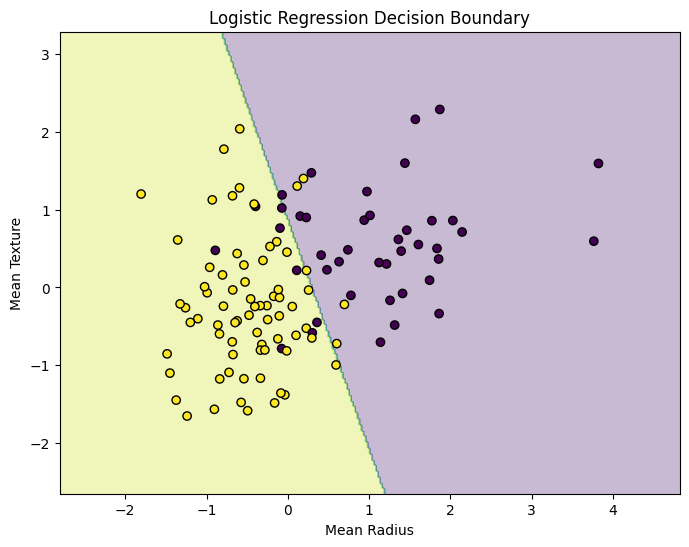

In [ ]:
plot_decision_boundary(
    logistic_2,
    X_test_2,
    y_test_2,
    "Logistic Regression Decision Boundary"
)

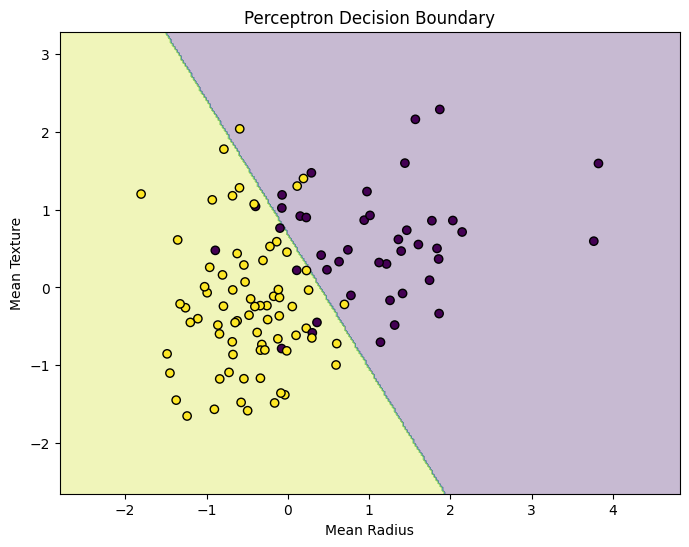

In [ ]:
plot_decision_boundary(
    perceptron_2,
    X_test_2,
    y_test_2,
    "Perceptron Decision Boundary"
)

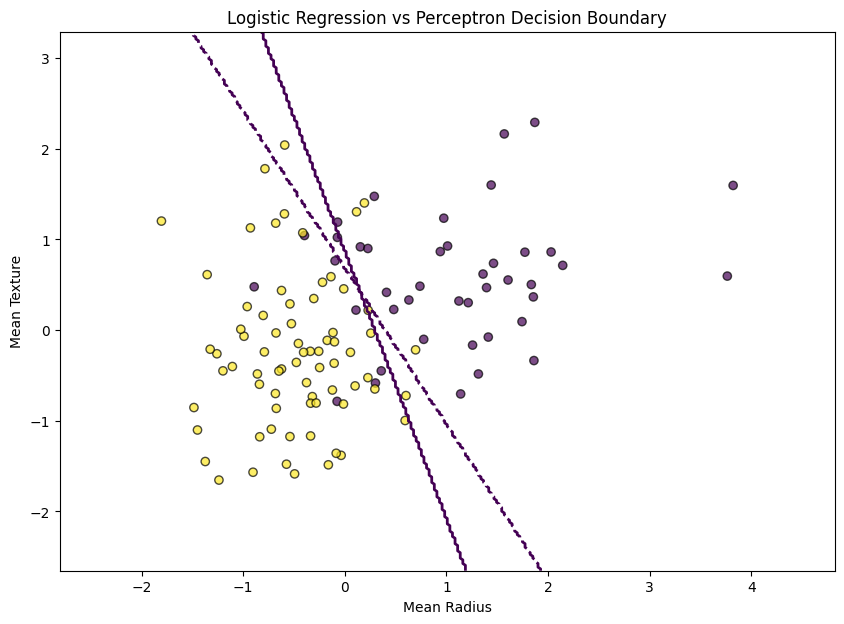

In [ ]:
def plot_both_boundaries():

    x_min = X_test_2[:, 0].min() - 1
    x_max = X_test_2[:, 0].max() + 1
    y_min = X_test_2[:, 1].min() - 1
    y_max = X_test_2[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predictions
    lr_pred = logistic_2.predict(grid).reshape(xx.shape)
    p_pred = perceptron_2.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(10, 7))

    # Plot data points
    plt.scatter(
        X_test_2[:, 0],
        X_test_2[:, 1],
        c=y_test_2,
        edgecolors='k',
        alpha=0.7
    )

    # Logistic Regression boundary
    plt.contour(
        xx,
        yy,
        lr_pred,
        levels=[0.5],
        linewidths=2
    )

    # Perceptron boundary
    plt.contour(
        xx,
        yy,
        p_pred,
        levels=[0.5],
        linestyles='--',
        linewidths=2
    )

    plt.xlabel("Mean Radius")
    plt.ylabel("Mean Texture")

    plt.title("Logistic Regression vs Perceptron Decision Boundary")

    plt.show()


plot_both_boundaries()

In [ ]:
print("==============================================")
print("       LAB EXPERIMENT 2 - FINAL RESULTS")
print("==============================================")

print("\nLogistic Regression:")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1-Score :", round(f1_lr, 4))

print("\nPerceptron:")
print("Accuracy :", round(accuracy_p, 4))
print("Precision:", round(precision_p, 4))
print("Recall   :", round(recall_p, 4))
print("F1-Score :", round(f1_p, 4))

print("\n==============================================")

       LAB EXPERIMENT 2 - FINAL RESULTS

Logistic Regression:
Accuracy : 0.9737
Precision: 0.9859
Recall   : 0.9722
F1-Score : 0.979

Perceptron:
Accuracy : 0.9474
Precision: 0.9583
Recall   : 0.9583
F1-Score : 0.9583

